In [22]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Input

In [23]:
# 2. Load Google Stock Price Dataset
df = pd.read_csv("Google_Stock_Price.csv")
print(df.head())

       Date    Open    High     Low   Close      Volume
0  1/3/2012  325.25  332.83  324.97  663.59   7,380,500
1  1/4/2012  331.27  333.87  329.08  666.45   5,749,400
2  1/5/2012  329.83  330.75  326.89  657.21   6,590,300
3  1/6/2012  328.34  328.77  323.68  648.24   5,405,900
4  1/9/2012  322.04  322.29  309.46  620.76  11,688,800


In [24]:
# 3. Prepare and Scale Data
data = pd.to_numeric(df['Open'], errors='coerce').dropna().values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [25]:
# 4. Split into Train and Test
train_size = int(len(data_scaled) * 0.8)
train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [26]:
# 5. Create Time Series Dataset (use past 60 days to predict next day)
def create_dataset(dataset):
    X, y = [], []
    for i in range(60, len(dataset)):
        X.append(dataset[i-60:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)

# Reshape for RNN: [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [27]:
# 6. Build RNN Model
model = Sequential()
model.add(Input(shape=(60, 1)))
model.add(SimpleRNN(50, return_sequences=True))
model.add(SimpleRNN(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 60, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# 7. Train RNN Model
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0118
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.5193e-04
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.9637e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8251e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.5525e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.1130e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7683e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5144e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.5116e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.3536e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.2013e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.4792e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.2022e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.4850e-04
Epoch 15/20
30/30 ━━━━━━━━━━━━━━━

In [29]:
# 8. Make Predictions
predicted = model.predict(X_test)

# Convert back to original scale
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1, 1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


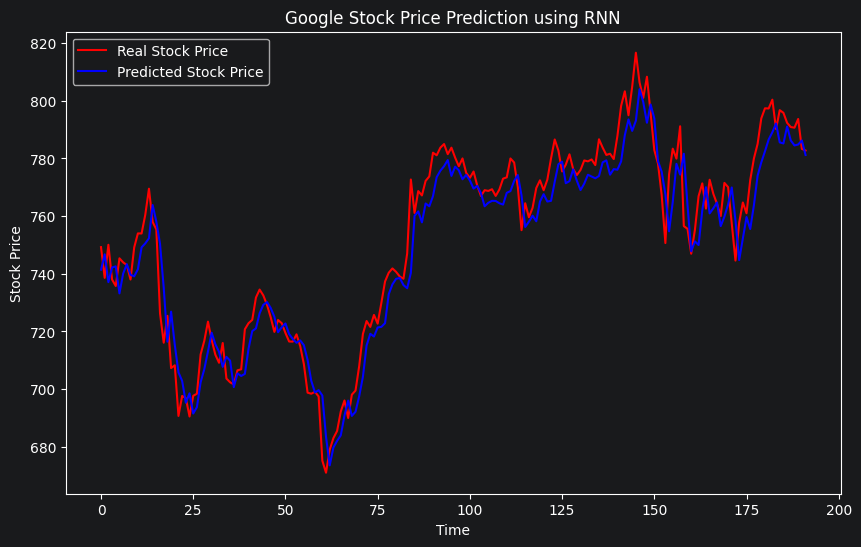

In [30]:
# 9. Plot Results
plt.figure(figsize=(10, 6))
plt.plot(real, color='red', label='Real Stock Price')
plt.plot(predicted, color='blue', label='Predicted Stock Price')
plt.title("Google Stock Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()